# Crude Oil Production and Demand Analysis

## Data Processing

This analysis focuses on crude oil production and demand:

1. Use NEWSAPIORG_KEY from .env to get Headlines from newsapi.org

    1.1. Source filter: CNN, Bloomberg, MSNBC, Reuters, The Washington Post, The Wall Street Journal

    1.2. Keyword filter: crude oil OR petroleum OR WTI OR Brent

    1.3. Create a DataFrame with ONLY columns: Date/Time, Headline, Source

    1.4. Create Visualisation for source and time distribution of the articles

2. Create Manual Topics: oil_demand, oil_production

3. Use FinBERT to do the following:

    3.1 Classify each headline into one of the manual topics

    3.2 Calculate a sentiment score and confidence for each headline categorised in each topic

    3.3 Output a DataFrame with following columns: Date/Time, Headline, Source, Topic, Sentiment, Confidence

    3.4. Create visualisation for: Sentiment distribution per topic, headline distribution in each topic, confidence level for each topic

4. Analyze relationship between sentiment and WTI price changes

In [32]:
# Core imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# API imports
from newsapi import NewsApiClient
import requests

# Set plotting style
plt.style.use('ggplot')

# Load environment variables
load_dotenv()

print("✓ Imports loaded successfully")


✓ Imports loaded successfully


---
## Part 1: NewsAPI.org
Getting crude oil headlines from newsapi.org


In [33]:
# Initialize NewsAPI.org client
api_key_org = os.getenv('NEWSAPIORG_KEY')
newsapi = NewsApiClient(api_key=api_key_org)

# Define search parameters - FOCUS ON CRUDE OIL ONLY
ENERGY_KEYWORDS = '(crude oil OR petroleum OR WTI OR Brent)'
SOURCES = 'al-jazeera-english, associated-press, australian-financial-review, bbc-news, bloomberg, cnn, financial-post, google-news, msnbc, reuters, the-wall-street-journal, the-washington-post'

print(f"API Key loaded: {'✓' if api_key_org else '✗'}")
print(f"Keywords: {ENERGY_KEYWORDS}")
print(f"Sources: {SOURCES}")


API Key loaded: ✓
Keywords: (crude oil OR petroleum OR WTI OR Brent)
Sources: al-jazeera-english, associated-press, australian-financial-review, bbc-news, bloomberg, cnn, financial-post, google-news, msnbc, reuters, the-wall-street-journal, the-washington-post


In [34]:
# Fetch articles from NewsAPI.org
print("Fetching articles from NewsAPI.org...")

try:
    articles_org = newsapi.get_everything(
        q=ENERGY_KEYWORDS,
        sources=SOURCES,
        language='en',
        sort_by='publishedAt',
        page_size=100
    )
    
    print(f"Total results available: {articles_org['totalResults']}")
    print(f"Articles retrieved: {len(articles_org['articles'])}")
    
    # Convert to DataFrame
    df_org = pd.DataFrame(articles_org['articles'])
    
    # Process source column
    if 'source' in df_org.columns:
        df_org['source_id'] = df_org['source'].apply(lambda x: x['id'] if x else None)
        df_org['source_name'] = df_org['source'].apply(lambda x: x['name'] if x else None)
    
    # Parse dates
    df_org['date'] = pd.to_datetime(df_org['publishedAt']).dt.date
    
    print(f"\n✓ DataFrame created with shape: {df_org.shape}")
    
except Exception as e:
    print(f"✗ Error: {e}")
    df_org = pd.DataFrame()


Fetching articles from NewsAPI.org...
Total results available: 194
Articles retrieved: 100

✓ DataFrame created with shape: (100, 11)


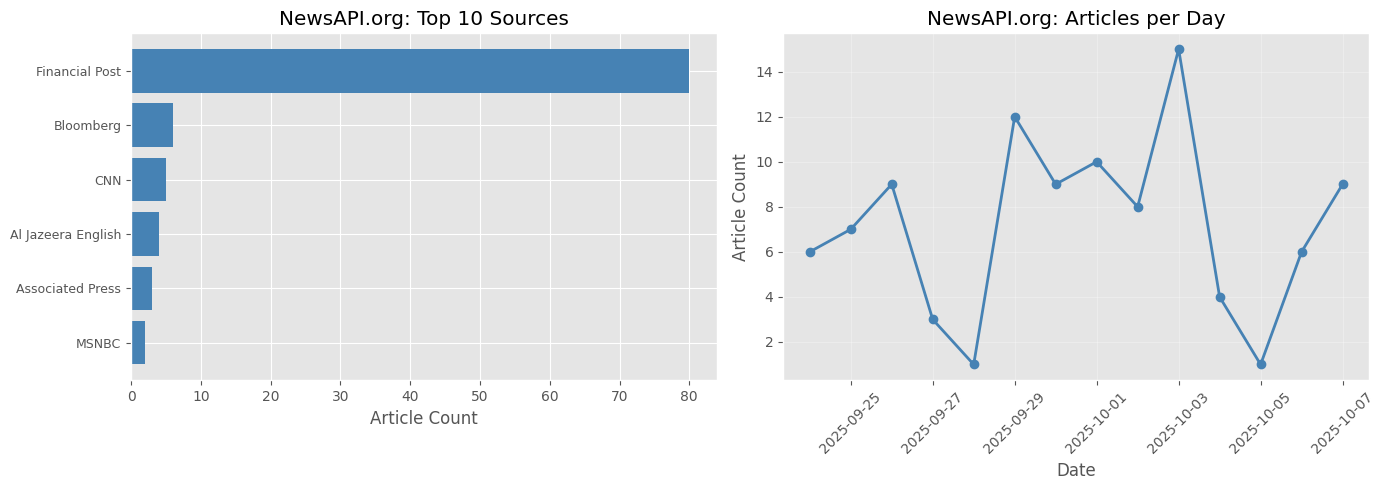

In [35]:
# Visualize NewsAPI.org data
if not df_org.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Source distribution
    source_counts = df_org['source_name'].value_counts().head(10)
    axes[0].barh(range(len(source_counts)), source_counts.values, color='steelblue')
    axes[0].set_yticks(range(len(source_counts)))
    axes[0].set_yticklabels(source_counts.index, fontsize=9)
    axes[0].set_xlabel('Article Count')
    axes[0].set_title('NewsAPI.org: Top 10 Sources')
    axes[0].invert_yaxis()
    
    # Temporal distribution
    articles_per_day = df_org.groupby('date').size().sort_index()
    axes[1].plot(articles_per_day.index, articles_per_day.values, 
                 marker='o', linewidth=2, color='steelblue')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Article Count')
    axes[1].set_title('NewsAPI.org: Articles per Day')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize")


---
## Part 2: FinBERT Topic Classification & Sentiment Analysis
Classify headlines into oil production/demand and analyze sentiment

In [36]:
# FinBERT Setup
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

print("Loading FinBERT model...")
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
finbert_model.to(device)

print(f"✓ FinBERT loaded on {device}")


Loading FinBERT model...
✓ FinBERT loaded on cpu


In [37]:
# Define manual topics with refined keywords for crude oil only
TOPICS = {
    'oil_production': [
        'oil production', 'crude production', 'oil output', 'petroleum production',
        'opec production', 'opec+', 'oil supply', 'crude supply', 'drilling',
        'oil exports', 'crude exports', 'production cut', 'production increase',
        'oil producers', 'shale oil', 'offshore production', 'refinery output'
    ],
    'oil_demand': [
        'oil demand', 'crude demand', 'oil consumption', 'petroleum demand',
        'fuel consumption', 'oil imports', 'crude imports', 'demand outlook',
        'consumption forecast', 'demand growth', 'demand decline', 'oil appetite',
        'refinery demand', 'energy demand'
    ]
}

def classify_topic(headline):
    """
    Classify headline into oil_production or oil_demand based on keywords
    Uses weighted scoring system for better classification
    """
    headline_lower = headline.lower()
    
    # Score-based classification for better accuracy
    production_score = 0
    demand_score = 0
    
    # Check explicit keywords
    for keyword in TOPICS['oil_production']:
        if keyword in headline_lower:
            production_score += 2
    
    for keyword in TOPICS['oil_demand']:
        if keyword in headline_lower:
            demand_score += 2
    
    # Additional context clues
    production_indicators = ['supply', 'output', 'produc', 'drill', 'export', 'opec', 'cut', 'barrel']
    demand_indicators = ['demand', 'consum', 'import', 'appetite', 'outlook', 'forecast', 'growth']
    
    for indicator in production_indicators:
        if indicator in headline_lower:
            production_score += 1
    
    for indicator in demand_indicators:
        if indicator in headline_lower:
            demand_score += 1
    
    # Return topic with higher score
    if production_score > demand_score:
        return 'oil_production'
    elif demand_score > production_score:
        return 'oil_demand'
    else:
        # Default fallback - check for key production terms
        if any(term in headline_lower for term in ['opec', 'supply', 'produc', 'drill', 'export']):
            return 'oil_production'
        else:
            return 'oil_demand'

print("✓ Topic classification ready")
print(f"Topics: {list(TOPICS.keys())}")


✓ Topic classification ready
Topics: ['oil_production', 'oil_demand']


In [38]:
def analyze_sentiment(text, tokenizer, model, device):
    """
    Analyze sentiment using FinBERT
    Returns sentiment score from -1 (negative) to +1 (positive) and confidence
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    # FinBERT outputs: [positive, negative, neutral]
    scores = predictions.cpu().numpy()[0]
    positive_score = float(scores[0])
    negative_score = float(scores[1])
    
    # Sentiment score: positive - negative (range -1 to 1)
    sentiment_score = positive_score - negative_score
    
    # Confidence: max probability
    confidence = float(np.max(scores))
    
    return sentiment_score, confidence

print("✓ Sentiment analysis function ready")


✓ Sentiment analysis function ready


In [39]:
# Process headlines: topic classification + sentiment analysis
print("Processing headlines...")

results = []
for idx, row in tqdm(df_org.iterrows(), total=len(df_org), desc="Analyzing"):
    headline = row['title']
    
    # Topic classification
    topic = classify_topic(headline)
    
    # Sentiment analysis (score from -1 to 1)
    sentiment_score, confidence = analyze_sentiment(headline, tokenizer, finbert_model, device)
    
    results.append({
        'date_time': row['publishedAt'],
        'headline': headline,
        'source': row['source_name'],
        'topic': topic,
        'sentiment': sentiment_score,
        'confidence': confidence
    })

# Create results DataFrame
df_results = pd.DataFrame(results)

print(f"\n✓ Processed {len(df_results)} headlines")
print(f"\nColumns: {list(df_results.columns)}")
df_results.head()


Processing headlines...


Analyzing: 100%|██████████| 100/100 [00:05<00:00, 18.90it/s]


✓ Processed 100 headlines

Columns: ['date_time', 'headline', 'source', 'topic', 'sentiment', 'confidence']


,date_time,headline,source,topic,sentiment,confidence
0,2025-10-07T11:20:51Z,OMV Plans Fourfold Increase in EV Chargers in ...,Financial Post,oil_demand,0.878833,0.887015
1,2025-10-07T11:10:31Z,Nayara energy revives fuel sales to Brazil and...,Bloomberg,oil_demand,0.921166,0.934567
2,2025-10-07T10:50:15Z,Sanctions-Hit Nayara Energy Revives Fuel Sales...,Financial Post,oil_demand,-0.417150,0.685220
3,2025-10-07T09:13:06Z,Shell’s Gas Stations in Indonesia Run Dry Agai...,Financial Post,oil_demand,-0.949063,0.962240
4,2025-10-07T08:42:30Z,Shell signals energy trading rebound in boost ...,Bloomberg,oil_demand,0.716057,0.774167


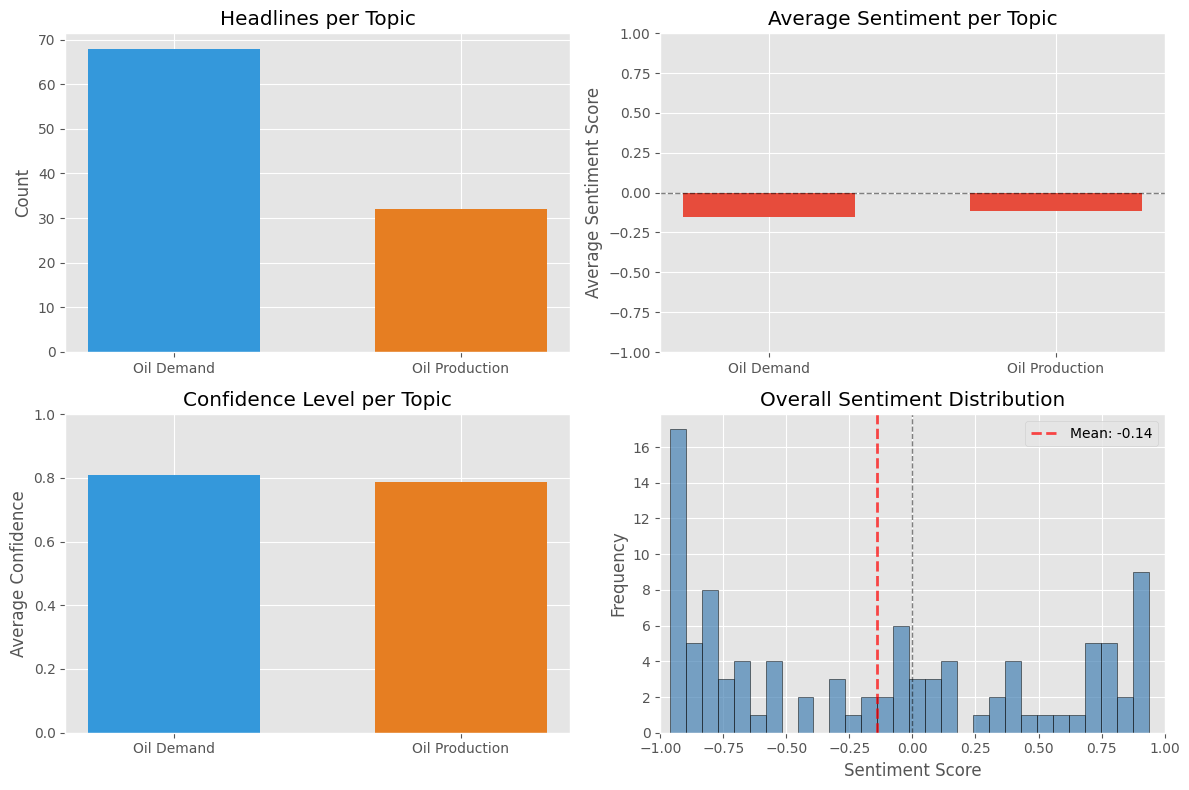

In [40]:
# Visualizations - Crude Oil Production & Demand Focus
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Headline distribution per topic
topic_counts = df_results['topic'].value_counts().sort_index()
axes[0, 0].bar(range(len(topic_counts)), topic_counts.values, 
               color=['#3498db', '#e67e22'], width=0.6)
axes[0, 0].set_xticks(range(len(topic_counts)))
axes[0, 0].set_xticklabels([t.replace('_', ' ').title() for t in topic_counts.index], rotation=0)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Headlines per Topic')

# 2. Average sentiment per topic
topic_sentiment = df_results.groupby('topic')['sentiment'].mean().sort_index()
colors_sent = ['#e74c3c' if x < 0 else '#2ecc71' for x in topic_sentiment.values]
axes[0, 1].bar(range(len(topic_sentiment)), topic_sentiment.values, 
               color=colors_sent, width=0.6)
axes[0, 1].set_xticks(range(len(topic_sentiment)))
axes[0, 1].set_xticklabels([t.replace('_', ' ').title() for t in topic_sentiment.index], rotation=0)
axes[0, 1].set_ylabel('Average Sentiment Score')
axes[0, 1].set_title('Average Sentiment per Topic')
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_ylim([-1, 1])

# 3. Confidence level per topic
topic_confidence = df_results.groupby('topic')['confidence'].mean().sort_index()
axes[1, 0].bar(range(len(topic_confidence)), topic_confidence.values, 
               color=['#3498db', '#e67e22'], width=0.6)
axes[1, 0].set_xticks(range(len(topic_confidence)))
axes[1, 0].set_xticklabels([t.replace('_', ' ').title() for t in topic_confidence.index], rotation=0)
axes[1, 0].set_ylabel('Average Confidence')
axes[1, 0].set_title('Confidence Level per Topic')
axes[1, 0].set_ylim([0, 1])

# 4. Overall sentiment distribution (histogram)
axes[1, 1].hist(df_results['sentiment'], bins=30, color='steelblue', 
                edgecolor='black', alpha=0.7, linewidth=0.5)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axvline(df_results['sentiment'].mean(), color='red', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f"Mean: {df_results['sentiment'].mean():.2f}")
axes[1, 1].set_xlabel('Sentiment Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Overall Sentiment Distribution')
axes[1, 1].set_xlim([-1, 1])
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## Part 3: WTI Price Analysis
Analyze relationship between sentiment scores and WTI crude oil price changes

In [41]:
# Load WTI price data
wti_path = 'WTI.csv'
df_wti = pd.read_csv(wti_path)

# Convert Unix timestamp to datetime
df_wti['datetime'] = pd.to_datetime(df_wti['time'], unit='s')

# Sort by datetime
df_wti = df_wti.sort_values('datetime').reset_index(drop=True)

print(f"✓ WTI data loaded: {len(df_wti)} records")
print(f"Date range: {df_wti['datetime'].min()} to {df_wti['datetime'].max()}")
print(f"\nWTI DataFrame shape: {df_wti.shape}")
df_wti.head()


✓ WTI data loaded: 1267 records
Date range: 2025-07-18 17:00:00 to 2025-10-03 20:00:00

WTI DataFrame shape: (1267, 4)


,time,close,Volume,datetime
0,1752858000,65.99,6541,2025-07-18 17:00:00
1,1752861600,66.16,9155,2025-07-18 18:00:00
2,1752865200,66.06,4790,2025-07-18 19:00:00
3,1752868800,66.03,2455,2025-07-18 20:00:00
4,1753048800,66.26,1714,2025-07-20 22:00:00


In [42]:
def get_price_change(headline_time, wti_df):
    """
    Get WTI price change in the hour following the headline
    Returns price change or None if data not available
    """
    headline_dt = pd.to_datetime(headline_time)
    
    # Convert to timezone-naive if timezone-aware (to match WTI data)
    if headline_dt.tz is not None:
        headline_dt = headline_dt.tz_convert('UTC').tz_localize(None)
    
    one_hour_later = headline_dt + timedelta(hours=1)
    
    # Find closest price at headline time
    time_diff = abs(wti_df['datetime'] - headline_dt)
    closest_idx = time_diff.idxmin()
    
    # Check if closest price is within 30 minutes
    if time_diff[closest_idx] > timedelta(minutes=30):
        return None
    
    price_at_headline = wti_df.loc[closest_idx, 'close']
    
    # Find price one hour later
    future_prices = wti_df[wti_df['datetime'] >= one_hour_later]
    if len(future_prices) == 0:
        return None
    
    price_one_hour_later = future_prices.iloc[0]['close']
    
    # Calculate price change
    price_change = price_one_hour_later - price_at_headline
    
    return price_change

print("✓ Price change function defined")


✓ Price change function defined


In [43]:
# Calculate price changes for each headline
print("Calculating price changes...")

df_results['price_change'] = df_results['date_time'].apply(
    lambda x: get_price_change(x, df_wti)
)

# Filter out rows where price change couldn't be calculated
df_analysis = df_results.dropna(subset=['price_change']).copy()

print(f"\n✓ Price changes calculated")
print(f"Headlines with matching WTI data: {len(df_analysis)} / {len(df_results)}")
print(f"\nSample data:")
df_analysis[['date_time', 'headline', 'topic', 'sentiment', 'price_change']].head()


Calculating price changes...

✓ Price changes calculated
Headlines with matching WTI data: 70 / 100

Sample data:


,date_time,headline,topic,sentiment,price_change
22,2025-10-03T17:52:02Z,Fire Shuts Chevron Refinery Units Near LA as F...,oil_demand,-0.913659,-0.05
23,2025-10-03T17:06:16Z,Vitol Piles Into North Sea Oil Despite Risk of...,oil_demand,0.854320,-0.41
24,2025-10-03T15:19:09Z,Oil at Sea Soars to Most Since 2023 in Sign of...,oil_production,0.809973,0.10
25,2025-10-03T13:11:34Z,Russia’s Spare Oil Export Capacity Running Out...,oil_production,-0.940119,0.15
26,2025-10-03T13:01:10Z,Ukraine Claims Attack on Orsk Oil Refinery Dee...,oil_demand,-0.779393,0.15


In [44]:
# Linear regression analysis
from scipy import stats

print("Linear Regression Analysis by Topic")
print("=" * 60)

regression_results = {}

for topic in df_analysis['topic'].unique():
    topic_data = df_analysis[df_analysis['topic'] == topic]
    
    if len(topic_data) < 3:  # Need at least 3 points for regression
        print(f"\n{topic.replace('_', ' ').title()}: Insufficient data (n={len(topic_data)})")
        continue
    
    X = topic_data['sentiment'].values
    y = topic_data['price_change'].values
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)
    
    regression_results[topic] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'n': len(topic_data)
    }
    
    print(f"\n{topic.replace('_', ' ').title()}:")
    print(f"  n = {len(topic_data)}")
    print(f"  Slope: {slope:.4f}")
    print(f"  Intercept: {intercept:.4f}")
    print(f"  R²: {r_value**2:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  {'Significant' if p_value < 0.05 else 'Not significant'} (α=0.05)")

print("\n" + "=" * 60)


Linear Regression Analysis by Topic

Oil Demand:
  n = 47
  Slope: -0.0196
  Intercept: 0.0065
  R²: 0.0018
  p-value: 0.7794
  Not significant (α=0.05)

Oil Production:
  n = 23
  Slope: 0.1141
  Intercept: 0.0402
  R²: 0.1030
  p-value: 0.1355
  Not significant (α=0.05)



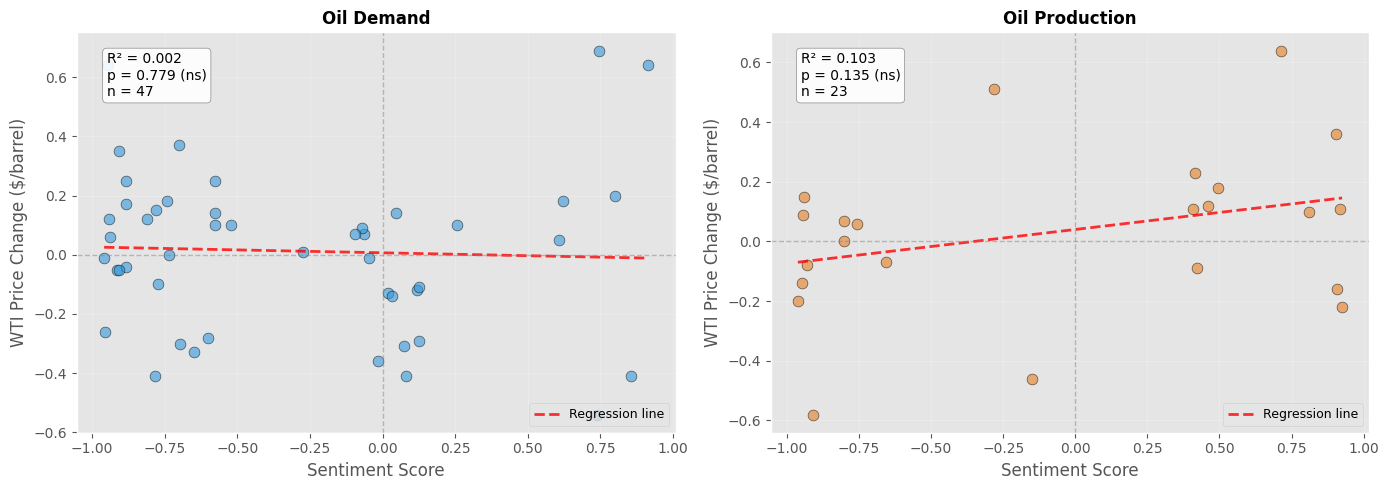

In [45]:
# Create 1x2 subplot visualization for Oil Production & Demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

topics = ['oil_demand', 'oil_production']
colors = ['#3498db', '#e67e22']

for idx, topic in enumerate(topics):
    ax = axes[idx]
    topic_data = df_analysis[df_analysis['topic'] == topic]
    
    if len(topic_data) < 3:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={len(topic_data)})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(topic.replace('_', ' ').title(), fontsize=12, weight='bold')
        ax.set_xlabel('Sentiment Score')
        ax.set_ylabel('WTI Price Change ($/barrel)')
        continue
    
    X = topic_data['sentiment'].values
    y = topic_data['price_change'].values
    
    # Scatter plot
    ax.scatter(X, y, alpha=0.6, s=60, color=colors[idx], edgecolors='black', linewidth=0.5)
    
    # Regression line
    if topic in regression_results:
        slope = regression_results[topic]['slope']
        intercept = regression_results[topic]['intercept']
        r_squared = regression_results[topic]['r_squared']
        p_value = regression_results[topic]['p_value']
        
        x_line = np.array([X.min(), X.max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2, alpha=0.8, label='Regression line')
        
        # Add statistics text
        sig_text = '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
        stats_text = f'R² = {r_squared:.3f}\np = {p_value:.3f} ({sig_text})\nn = {len(topic_data)}'
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_title(topic.replace('_', ' ').title(), fontsize=12, weight='bold')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('WTI Price Change ($/barrel)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


In [46]:
# Summary statistics for Crude Oil Analysis
print("=" * 70)
print("CRUDE OIL PRODUCTION & DEMAND ANALYSIS - SUMMARY")
print("=" * 70)

print(f"\nData Overview:")
print(f"  Total headlines analyzed: {len(df_results)}")
print(f"  Headlines with WTI price data: {len(df_analysis)}")

print(f"\nTopic Breakdown:")
topics_sorted = ['oil_demand', 'oil_production']
for topic in topics_sorted:
    count = len(df_analysis[df_analysis['topic'] == topic])
    avg_sent = df_analysis[df_analysis['topic'] == topic]['sentiment'].mean()
    print(f"  {topic.replace('_', ' ').title()}: {count} headlines (avg sentiment: {avg_sent:.3f})")

print(f"\nSentiment Statistics:")
print(f"  Range: [{df_analysis['sentiment'].min():.3f}, {df_analysis['sentiment'].max():.3f}]")
print(f"  Mean: {df_analysis['sentiment'].mean():.3f}")
print(f"  Std Dev: {df_analysis['sentiment'].std():.3f}")

print(f"\nWTI Price Change Statistics:")
print(f"  Range: [{df_analysis['price_change'].min():.3f}, {df_analysis['price_change'].max():.3f}] $/barrel")
print(f"  Mean: {df_analysis['price_change'].mean():.3f} $/barrel")
print(f"  Std Dev: {df_analysis['price_change'].std():.3f} $/barrel")

# Overall correlation (all topics combined)
overall_corr = df_analysis[['sentiment', 'price_change']].corr().iloc[0, 1]
print(f"\nOverall Correlation:")
print(f"  Sentiment vs Price Change: {overall_corr:.4f}")

print("\n" + "=" * 70)


CRUDE OIL PRODUCTION & DEMAND ANALYSIS - SUMMARY

Data Overview:
  Total headlines analyzed: 100
  Headlines with WTI price data: 70

Topic Breakdown:
  Oil Demand: 47 headlines (avg sentiment: -0.299)
  Oil Production: 23 headlines (avg sentiment: -0.074)

Sentiment Statistics:
  Range: [-0.962, 0.925]
  Mean: -0.225
  Std Dev: 0.657

WTI Price Change Statistics:
  Range: [-0.580, 0.690] $/barrel
  Mean: 0.019 $/barrel
  Std Dev: 0.273 $/barrel

Overall Correlation:
  Sentiment vs Price Change: 0.1004

